In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from sklearn.model_selection import train_test_split
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Column names for the Pima Indians Diabetes Dataset
column_names = [
   "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
   "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

In [3]:
# Load dataset using pandas with column names
df = pd.read_csv("pima-indians-diabetes.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("Column Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Column Names: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Basic Statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Features: all columns except Outcome
X = df.drop(columns=["Outcome"]).values

In [7]:
# Target: Outcome column (0 = No Diabetes, 1 = Diabetes)
y = df["Outcome"].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)

In [9]:
train_size = len(X_train)
test_size  = len(X_test)
batch_size = 10
print(f"Train size : {train_size}")
print(f"Test size  : {test_size}")
print(f"Batch size : {batch_size}")


Train size : 614
Test size  : 154
Batch size : 10


In [10]:
model = Sequential([
   InputLayer(input_shape=(8,)),        # 8 input features
   Dense(12, activation="relu"),        # Hidden layer 1
   Dense(8,  activation="relu"),        # Hidden layer 2
   Dense(1,  activation="sigmoid")      # Output: probability (0 = non-diabetic, 1 = diabetic)
])

c:\Users\jebarajj\OneDrive - Bristol Myers Squibb\Documents\Python\gen-ai\venv\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# binary_crossentropy is appropriate for binary classification
model.compile(
   loss="binary_crossentropy",
   optimizer="adam",
   metrics=["accuracy"]
)
print("Model compiled!")

Model compiled!


In [13]:
history = model.fit(
   X_train, y_train,
   epochs=150,
   batch_size=batch_size,
   validation_split=0.1,
   verbose=1
)
print("\nTraining complete!")

Epoch 1/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3659 - loss: 11.5730 - val_accuracy: 0.3871 - val_loss: 5.6823
Epoch 2/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4964 - loss: 3.2306 - val_accuracy: 0.5161 - val_loss: 1.0444
Epoch 3/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5688 - loss: 1.0572 - val_accuracy: 0.6290 - val_loss: 0.7341
Epoch 4/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5851 - loss: 0.8739 - val_accuracy: 0.6452 - val_loss: 0.7294
Epoch 5/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6123 - loss: 0.7991 - val_accuracy: 0.6452 - val_loss: 0.6923
Epoch 6/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6250 - loss: 0.7751 - val_accuracy: 0.6290 - val_loss: 0.6742
Epoch 7/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6069 - loss: 0.7522 - val_accuracy: 0.6129 - val_loss: 0.6828
Epoch 8/150
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6159 - loss: 0.7305 - val_accuracy: 0.6613 - 

In [14]:
predictions = model.predict(X_test)
header = f"{"#":<4}  {"Preg":>5} {"Gluc":>5} {"BP":>5} {"Skin":>5} {"Ins":>6} {"BMI":>6} {"DPF":>7} {"Age":>4}  {"Prob":>8}  {"Actual":>12}  {"Predicted":>12}"
print(header)
print("-" * len(header))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
#      Preg  Gluc    BP  Skin    Ins    BMI     DPF  Age      Prob        Actual     Predicted
----------------------------------------------------------------------------------------------


In [15]:
for i in range(5):
   row = X_test[i]
   prob = predictions[i][0]
   pred_label   = "Diabetic"     if prob >= 0.5    else "Non-Diabetic"
   actual_label = "Diabetic"     if y_test[i] == 1 else "Non-Diabetic"
   print(f"{i:<4}  {row[0]:>5.0f} {row[1]:>5.0f} {row[2]:>5.0f} {row[3]:>5.0f} {row[4]:>6.0f} {row[5]:>6.1f} {row[6]:>7.3f} {row[7]:>4.0f}  {prob:>8.4f}  {actual_label:>12}  {pred_label:>12}")

0         6    98    58    33    190   34.0   0.430   43    0.5610  Non-Diabetic      Diabetic
1         2   112    75    32      0   35.7   0.148   21    0.2472  Non-Diabetic  Non-Diabetic
2         2   108    64     0      0   30.8   0.158   21    0.2644  Non-Diabetic  Non-Diabetic
3         8   107    80     0      0   24.6   0.856   34    0.2523  Non-Diabetic  Non-Diabetic
4         7   136    90     0      0   29.9   0.210   50    0.4092  Non-Diabetic  Non-Diabetic


In [16]:
loss, accuracy = model.evaluate(X_test, y_test, batch_size=10, verbose=1)
print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7013 - loss: 0.6119 

Test Loss     : 0.6119
Test Accuracy : 70.13%


In [17]:
# Custom patient records — designed to cover typical cases
# [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DPF, Age]
custom_samples = np.array([
   [6,  148, 72, 35,   0, 33.6, 0.627, 50],   # Patient A — high glucose, older
   [1,   85, 66, 29,   0, 26.6, 0.351, 31],   # Patient B — low glucose, young
   [8,  183, 64,  0,   0, 23.3, 0.672, 32],   # Patient C — very high glucose
   [0,  137, 40, 35, 168, 43.1, 2.288, 33],   # Patient D — high insulin, obese
   [5,  116, 74,  0,   0, 25.6, 0.201, 30],   # Patient E — borderline features
   [3,   78, 50, 32,  88, 31.0, 0.248, 26],   # Patient F — younger, moderate values
])

In [18]:
patient_labels = ["Patient A", "Patient B", "Patient C", "Patient D", "Patient E", "Patient F"]
custom_preds = model.predict(custom_samples)
print(f"Patient       Probability    Diagnosis")
print("-" * 45)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Patient       Probability    Diagnosis
---------------------------------------------


In [19]:
for label, prob in zip(patient_labels, custom_preds):
   emoji     = "Diabetic (1)" if prob[0] >= 0.5 else "Non-Diabetic (0)"
   print(f"{label:<12}  {prob[0]:>12.4f}    {emoji}")

Patient A           0.6262    Diabetic (1)
Patient B           0.1354    Non-Diabetic (0)
Patient C           0.7615    Diabetic (1)
Patient D           0.8069    Diabetic (1)
Patient E           0.2739    Non-Diabetic (0)
Patient F           0.2377    Non-Diabetic (0)


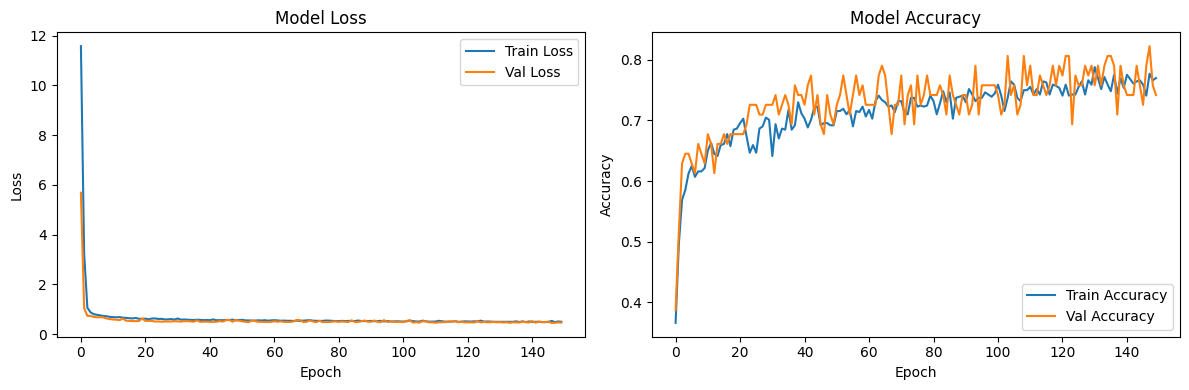

: 

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"],     label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_title("Model Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train Accuracy")
axes[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[1].set_title("Model Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()